# Solution 4

## Tamir Cohen

### Q1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

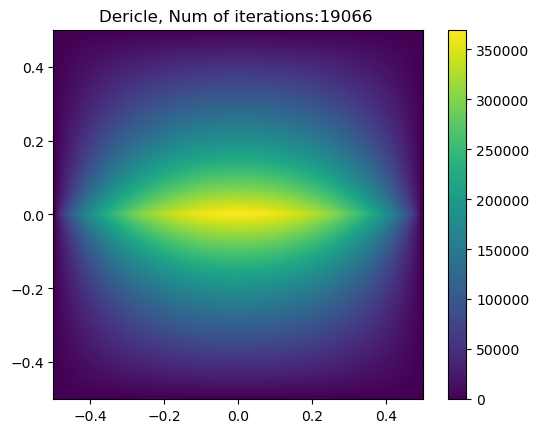

19066


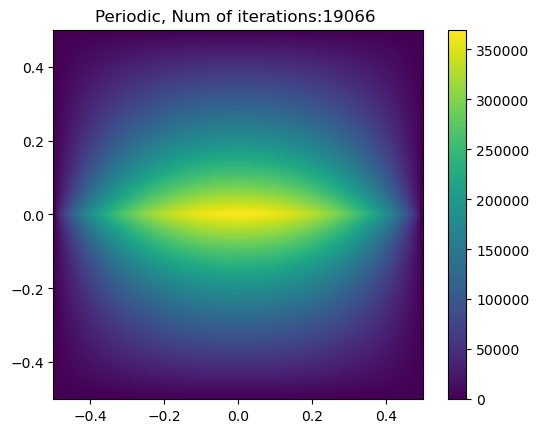

19066


In [34]:
def ghost_cell (phi,BC=0):
    # BC =0 dericle, BC = 1 periodic
    if BC == 0:
        phi_ =  np.zeros(np.array(phi.shape)+2)
        phi_[1:-1,1:-1] = phi.copy()
    
    elif BC == 1:
        phi_ =  np.zeros(np.array(phi.shape)+2)
        phi_[1:-1,1:-1] = phi.copy()
        phi_[0,:] = phi_[-2,:]
        phi_[-1,:] = phi_[1,:]
        phi_[:,0] = phi_[:,-2]
        phi_[:,-1] = phi_[:,1]
        
    
    return phi_

def err_fun(phi_prev,phi_new):
    # eps_max = np.sum(np.sum(np.abs(phi_new - phi_prev)))/len(phi_new)**2
    eps_max = np.max(np.max(np.abs(phi_new - phi_prev)**2))
    # print(np.max(phi_prev))
    # print(np.min((phi_new - phi_prev)**2))
    return eps_max


def  Poisson_func (phi=[],f=0, BC=0):
    Nx,Ny = np.array(phi.shape)
    x = np.linspace(-1/2,1/2,Nx+3)
    y = x = np.linspace(-1/2,1/2,Ny+3)
    N = Nx
    phi_= ghost_cell (phi, BC)
    # print(phi_.shape)
    f_  = ghost_cell (f, BC)
    # print(f_.shape)
    phi_new = phi_*0
    eps = 1;
    treshhold = 1e-1
    count = 0
    eps = err_fun(phi_,phi_new)
    while eps> treshhold:
        count+=1
        # phi_new = phi_*0
        for i in range(1,N+1):
            for j in range(1,N+1):
                phi_new[i,j] = 1/4 * (phi_[i+1,j] + phi_[i-1,j] + phi_[i,j+1] + phi_[i,j-1] + f_[i,j])
        eps = err_fun(phi_,phi_new)
        phi_ = phi_new.copy()
        # phi_ = ghost_cell(phi_[1:-1,1:-1])
        # phi_new = phi_*0
    plt.imshow(phi_,extent=[-1/2, 1/2, -1/2, 1/2]); plt.colorbar(); 
    if BC == 0 :
        plt.title (f'Dericle, Num of iterations:{count} ') 
    elif BC == 1:
        plt.title (f'Periodic, Num of iterations:{count} ') 
    plt.show()
    print (count)
    # print(phi_new)
    
def rho_mat_func(rho,N):
    N=N+1
    h = 1/(N+1)
    rho_norm = rho/h**2
    rho_mat= np.zeros([N,N]) # [raws,colmns]
    rho_mat[int(np.floor(N/2)),:] = rho_norm
    return rho_mat
    

def main(N = 2**5):
    phi0 = np.ones([N+1,N+1]) # [raws,colmns]
    rho = 1 #normlized to epsilon_0
    rho_mat = rho_mat_func(rho,N)
    BC = 0 # dericle
    Poisson_func (phi=phi0, f=rho_mat,BC=BC)
    BC = 1 # Periodic
    Poisson_func (phi=phi0, f=rho_mat,BC=BC)

if __name__ == "__main__":
    main()
    
    
    
    

### Q2

65


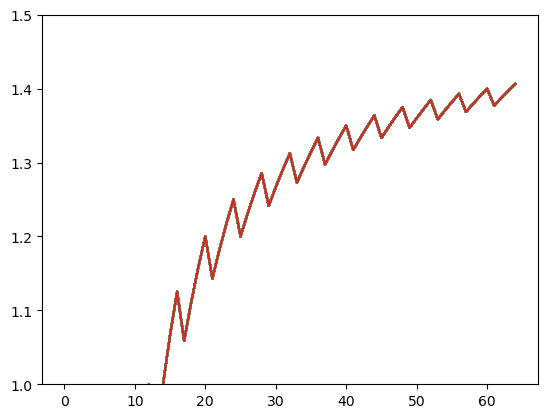

In [63]:
# plt_1 = plt.figure(1)   # handle to figure 1
# plt_2 = plt.figure(2)   # handle to figure 2
# plt_3 = plt.figure(3)   # handle to figure 2
# plt_4 = plt.figure(4)   # handle to figure 2

def step_func (Vec_len):
    N=Vec_len
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    u = np.zeros_like(x)
    u[x < 0.01] = 2      # left state
    u[x >= 0.01] = 1   # right state
    return  u

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[0] = a[0]
    a_[-1]  = a[-1]
    return a_

    
def upwind(u,C,question="a"):
    u_ = goust_func(u)
  
    if "a" in question:
        u_new = u - C*u*(u_[1:-1] - u_[:-2])   # length N
        
    elif "b" in question:
        F = 0.5*u_**2
        u_new = u - C*(F[1:-1] - F[:-2])   # length N
    return u_new            


def shock_spead_calc(C, step, dx, dt):
    shock_pos = np.zeros_like(step)
    shock_vel = np.zeros_like(step)
    print(len(step))
    for i in range(len(step)):
        shock_pos[i] = np.min((np.where(np.abs((step[i][:-1] - step[i][1:] ))))[0])
        # print(np.min((np.where(np.abs((step[i][:-1] - step[i][1:] ))>0.3))[0]))
                # shock_pos[i] = np.where(np.abs((step[i][1:] - step[i][:-1] )))[0][0]
        # shock_pos[i] = shock_pos[i]
#         dt = C / np.max(step)/dx #C/np.max(step)*dx*(i+1)
#         dt = C*dx
        if i==0:
            shock_vel[i] = 0
        else:
            shock_vel[i] =   (shock_pos[i] - shock_pos[0])/ (dt*i) *dx
        
#     print(np.mean(shock_vel))
    return shock_vel


def uni_advection(C=0.5, N=2**6, u=1, question = "a"):

    dx = 1/N; T = 1/u; dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(int(len(t_vec)/2)):
        step_ = upwind(step[-1],C,question)
        # print (step_)
        step.append(step_)

    shock_vel = shock_spead_calc(C, step, dx, dt)
    
    return step, shock_vel



    # print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")

if uni_advection:
    N_vec = np.array([2**10])#,2**7,2**8
    shock_vel_a = [[] for _ in range(len(N_vec))]
    step_a  = [[] for _ in range(len(N_vec))]
    N=2**6
    i = 0
    step_a[i], shock_vel_a[i] = uni_advection(N = N, question = "b"); 
    plt.plot(shock_vel_a[0]); plt.ylim(1,1.5);plt.show()
   
    
    # print(shock_vel_a[0])
    
    
    # for i in range(len(N_vec)):
    #     N = N_vec[i]
    #     step_a[i], shock_vel_a[i] = uni_advection(N = N, question = "a"); plt.show()
    # legend = list([])
    # for i in range(len(N_vec)):
    #     N = np.linspace(0,1,N_vec[i])
    #     plt.plot(shock_vel_a[i]); plt.xlim(0,10)
    #     legend.append(f"N = {N_vec[i]}")
    # plt.legend(legend)

    # shock_vel_b = [[] for _ in range(len(N_vec))]
    # step_b  = [[] for _ in range(len(N_vec))]
    # for i in range(len(N_vec)):
    #     N = N_vec[i]
    #     step_b[i], shock_vel_b[i] = uni_advection(N = N, question = "b"); plt.show()
    # legend = list([])
    
    # for i in range(len(N_vec)):
    #     plt.plot(shock_vel_b[i]); plt.xlim(0,10)
    #     legend.append(f"N = {N_vec[i]}")
    # plt.legend(legend)
    # plt.show()


    
    # uni_advection(N = 2**9, question = "a")
    # uni_advection(question = "b")        

    